# Camera Calibration

This section performs camera calibration using chessboard images to find the camera matrix and distortion coefficients.

In [10]:
import numpy as np
import cv2 as cv
import glob

# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((10*7,3), np.float32)
objp[:,:2] = np.mgrid[0:10,0:7].T.reshape(-1,2)

# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

images = glob.glob('*.jpg')

for fname in images:
    img = cv.imread(fname)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Find the chess board corners
    ret, corners = cv.findChessboardCorners(gray, (10, 7), None)

    # If found, add object points, image points (after refining them)
    if ret == True:
        objpoints.append(objp)

        corners2 = cv.cornerSubPix(gray,corners, (11,11), (-1,-1), criteria)
        imgpoints.append(corners2)


        # Draw and display the corners
        cv.drawChessboardCorners(img, (10,7), corners2, ret)
        cv.imshow('img', img)
        cv.waitKey(0)  
    if ret == False:
        print(f"Chessboard not found in {fname}")

cv.destroyAllWindows()
cv.waitKey(1)

ret, mtx, dist, rvecs, tvecs = cv.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)


### Camera Calibration Outputs Explanation

- **`mtx` (Camera Matrix)**: The intrinsic camera matrix containing focal lengths (fx, fy) in pixels and optical center (cx, cy). These are internal camera properties independent of position.
- **`dist` (Distortion Coefficients)**: Coefficients for radial and tangential distortion, used to correct lens imperfections.
- **`rvecs` and `tvecs`**: Extrinsic parameters (rotation and translation vectors) for each chessboard image, describing the camera's pose relative to the board.

In [11]:
img = cv.imread('Foto op 08-03-2026 om 13.46 #3.jpg')
h,  w = img.shape[:2]
newcameramtx, roi = cv.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))

In [ ]:
# Print the calibration matrices, distortion coefficients, new camera matrix, and ROI for easy copying into other scripts or global calibration blocks
print("mtx = np.array(" + np.array2string(mtx, separator=', ') + ")")
print("dist = np.array(" + np.array2string(dist, separator=', ') + ")")
print("newcameramtx = np.array(" + np.array2string(newcameramtx, separator=', ') + ")")
print("roi =", roi)

mtx = np.array([[2.00313622e+03, 0.00000000e+00, 1.13719259e+03],
 [0.00000000e+00, 2.00602079e+03, 7.34877818e+02],
 [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
dist = np.array([[-2.57939135e-02,  3.50765930e-01, -1.66865917e-04, -7.56033165e-04,
  -8.65799370e-01]])
newcameramtx = np.array([[1.93156188e+03, 0.00000000e+00, 1.13553543e+03],
 [0.00000000e+00, 1.94087193e+03, 7.31467517e+02],
 [0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])
roi = (39, 22, 2190, 1460)


## Image Undistortion

This section undistorts an image using the calibration parameters and displays the original and undistorted images side by side.

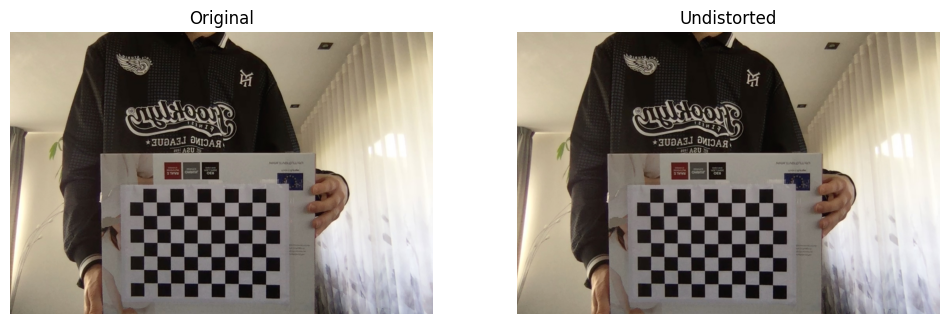

In [9]:
# undistort
mapx, mapy = cv.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w,h), 5)
dst = cv.remap(img, mapx, mapy, cv.INTER_LINEAR)

# crop the image
x, y, w, h = roi
dst = dst[y:y+h, x:x+w]
cv.imwrite('calibresult.png', dst)

# display original and undistorted side by side
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Undistorted')
plt.imshow(cv.cvtColor(dst, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.show()


## Calibration Error

This section calculates the mean reprojection error to evaluate the calibration accuracy.

In [14]:
mean_error = 0
for i in range(len(objpoints)):
    imgpoints2, _ = cv.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
    error = cv.norm(imgpoints[i], imgpoints2, cv.NORM_L2)/len(imgpoints2)
    mean_error += error

print( "total error: {}".format(mean_error/len(objpoints)) )

total error: 0.14200031155678408


## Distance Calibration

This section interactively calibrates the millimeters per pixel by clicking two points on an image with a known distance.

In [26]:
%matplotlib qt

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

img = mpimg.imread('Foto op 08-03-2026 om 13.46 #3.jpg')

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.set_ylim(1105, 1040)
ax.set_xlim(1000, 1170)
ax.set_title('Klik twee punten')

point1 = point2 = None

def onclick(event):
    global point1, point2
    if event.inaxes != ax: return
    
    if point1 is None:
        point1 = (event.xdata, event.ydata)
        ax.plot(point1[0], point1[1], 'ro', markersize=8)
        fig.canvas.draw()
    else:
        point2 = (event.xdata, event.ydata)
        ax.plot(point2[0], point2[1], 'go', markersize=8)
        dist = np.hypot(point2[0]-point1[0], point2[1]-point1[1])
        mm_per_pixel = 50.0 / dist
        print(f'Pixels: {dist:.2f}')
        print(f'Mm/pixel: {mm_per_pixel:.4f}')
        ax.plot([point1[0], point2[0]], [point1[1], point2[1]], 'r--')
        ax.set_title(f'{dist:.1f}px = 50mm | {mm_per_pixel:.4f}mm/px')
        fig.canvas.draw()

fig.canvas.mpl_connect('button_press_event', onclick)
plt.tight_layout()
plt.show()

# 0.4085 mm/px